# Projeto Completo: Classificacao e Regressao

Notebook refeito do zero conforme o enunciado, com blocos pequenos, explicativos e reutilizacao das separacoes de dados definidas no Topico 1.


## Roteiro do notebook

1. Carregar e inspecionar a base de dados
2. Topico 1: Separacao de dados para treino e teste (reutilizada adiante)
3. Etapa 1: Classificacao (3 modelos, 3 metodos de separacao)
4. Etapa 2: Regressao (3 modelos, 3 metodos de separacao)
5. Tabelas, graficos e interpretacao final


## 0) Preparacao do ambiente


In [1]:
# Importacoes principais
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, LinearSVR

warnings.filterwarnings('ignore', category=ConvergenceWarning)


In [2]:
# Configuracao visual simples para os graficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Ambiente pronto.')


Ambiente pronto.


## 1) Carregamento da base de dados


In [3]:
# Carregar a base principal do projeto
from pathlib import Path

# Tentamos dois caminhos para funcionar tanto no root quanto na pasta notebook
candidate_paths = [
    Path('datasets/dataset_avaliacoes.csv'),
    Path('../datasets/dataset_avaliacoes.csv')
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Nao encontrei datasets/dataset_avaliacoes.csv')

df = pd.read_csv(data_path)
print('Base carregada com sucesso de:', data_path)


Base carregada com sucesso de: ../datasets/dataset_avaliacoes.csv


In [4]:
# Visualizacao rapida da estrutura
print('Formato da base:', df.shape)
print('Colunas:', list(df.columns))
df.head()


Formato da base: (15501, 4)
Colunas: ['ID_avaliacao', 'avaliacao', 'nota', 'sentimento']


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [5]:
# Checagem de qualidade dos dados
print('Valores nulos por coluna:')
print(df.isna().sum())

print('\nLinhas duplicadas:', df.duplicated().sum())


Valores nulos por coluna:
ID_avaliacao    0
avaliacao       0
nota            0
sentimento      0
dtype: int64

Linhas duplicadas: 0


In [6]:
# Distribuicao das classes (classificacao) e do alvo continuo (regressao)
print('Distribuicao de sentimento:')
print(df['sentimento'].value_counts())

print('\nDistribuicao de nota:')
print(df['nota'].value_counts().sort_index())


Distribuicao de sentimento:
sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

Distribuicao de nota:
nota
1    5655
2    1956
4    3296
5    4594
Name: count, dtype: int64


### Justificativa da base escolhida

A base `dataset_avaliacoes.csv` atende os dois problemas do enunciado:
- **Classificacao**: possui o rotulo `sentimento` (positivo/negativo).
- **Regressao**: possui a variavel numerica `nota` (escala de 1 a 5).

Ou seja, uma unica base permite desenvolver as duas etapas de forma consistente.


## 2) Topico 1 - Separacao de dados para treinamento e teste

As separacoes abaixo sao a referencia oficial do projeto e serao reutilizadas nas etapas seguintes.


In [7]:
# Definir variaveis basicas para o projeto
X_text = df['avaliacao'].astype(str)
y_class_label = df['sentimento'].astype(str)
y_class = (y_class_label == 'positivo').astype(int)
y_reg = df['nota'].astype(float)

# Indices do dataset (iremos separar indices, nao o texto diretamente)
indices = np.arange(len(df))

print('X_text:', X_text.shape)
print('y_class:', y_class.shape)
print('y_reg:', y_reg.shape)


X_text: (15501,)
y_class: (15501,)
y_reg: (15501,)


In [8]:
# Metodo 1: Divisao Simples (80/20)
# Observacao: esta divisao sera reutilizada em classificacao e regressao
idx_train_simple, idx_test_simple = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print('Divisao simples criada:')
print('Treino:', len(idx_train_simple), '| Teste:', len(idx_test_simple))


Divisao simples criada:
Treino: 12400 | Teste: 3101


In [9]:
# Conferir distribuicao de classes na divisao simples
y_train_lbl = y_class_label.iloc[idx_train_simple]
y_test_lbl = y_class_label.iloc[idx_test_simple]

print('Distribuicao no treino (simples):')
print(y_train_lbl.value_counts())

print('\nDistribuicao no teste (simples):')
print(y_test_lbl.value_counts())


Distribuicao no treino (simples):
sentimento
positivo    6322
negativo    6078
Name: count, dtype: int64

Distribuicao no teste (simples):
sentimento
positivo    1568
negativo    1533
Name: count, dtype: int64


In [10]:
# Metodo 2: K-Fold Cross-Validation (sem estratificacao)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_splits = list(kfold.split(indices))

print('K-Fold criado com', len(kfold_splits), 'folds.')
for i, (tr, te) in enumerate(kfold_splits, start=1):
    print(f'Fold {i}: treino={len(tr)} | teste={len(te)}')


K-Fold criado com 5 folds.
Fold 1: treino=12400 | teste=3101
Fold 2: treino=12401 | teste=3100
Fold 3: treino=12401 | teste=3100
Fold 4: treino=12401 | teste=3100
Fold 5: treino=12401 | teste=3100


In [11]:
# Metodo 3 (Classificacao): Stratified K-Fold com base em sentimento
skf_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_kfold_class_splits = list(skf_class.split(indices, y_class))

print('Stratified K-Fold (classificacao) criado com', len(stratified_kfold_class_splits), 'folds.')
for i, (tr, te) in enumerate(stratified_kfold_class_splits, start=1):
    p_tr = y_class.iloc[tr].mean() * 100
    p_te = y_class.iloc[te].mean() * 100
    print(f'Fold {i}: %positivo treino={p_tr:.2f} | %positivo teste={p_te:.2f}')


Stratified K-Fold (classificacao) criado com 5 folds.
Fold 1: %positivo treino=50.90 | %positivo teste=50.89
Fold 2: %positivo treino=50.90 | %positivo teste=50.90
Fold 3: %positivo treino=50.90 | %positivo teste=50.90
Fold 4: %positivo treino=50.90 | %positivo teste=50.90
Fold 5: %positivo treino=50.90 | %positivo teste=50.90


In [12]:
# Metodo 3 (Regressao): Stratified K-Fold adaptado com faixas da nota
# Em regressao nao ha classes naturais, por isso usamos bins da variavel continua.
y_reg_bins = pd.qcut(y_reg, q=5, labels=False, duplicates='drop')
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_kfold_reg_splits = list(skf_reg.split(indices, y_reg_bins))

print('Stratified K-Fold (regressao com bins) criado com', len(stratified_kfold_reg_splits), 'folds.')
for i, (tr, te) in enumerate(stratified_kfold_reg_splits, start=1):
    m_tr = y_reg.iloc[tr].mean()
    m_te = y_reg.iloc[te].mean()
    print(f'Fold {i}: media nota treino={m_tr:.3f} | media nota teste={m_te:.3f}')


Stratified K-Fold (regressao com bins) criado com 5 folds.
Fold 1: media nota treino=2.946 | media nota teste=2.965
Fold 2: media nota treino=2.950 | media nota teste=2.946
Fold 3: media nota treino=2.952 | media nota teste=2.941
Fold 4: media nota treino=2.951 | media nota teste=2.945
Fold 5: media nota treino=2.949 | media nota teste=2.950


### Diferencas e vantagens dos metodos de separacao

- **Divisao Simples (80/20)**: rapida, facil de entender, boa para baseline.
- **K-Fold**: reduz dependencia de uma unica particao, pois faz media entre varios folds.
- **Stratified K-Fold**: melhora a justica da avaliacao ao preservar distribuicao do alvo (classes na classificacao, bins na regressao).

As estruturas criadas no Topico 1 (`idx_train_simple`, `kfold_splits`, `stratified_kfold_*_splits`) serao usadas nos codigos seguintes.


## 3) Etapa 1 - Classificacao


In [13]:
# Confirmar que as separacoes do Topico 1 existem antes de treinar
required_vars_cls = [
    'idx_train_simple',
    'idx_test_simple',
    'kfold_splits',
    'stratified_kfold_class_splits'
]
missing_cls = [v for v in required_vars_cls if v not in globals()]
if missing_cls:
    raise RuntimeError(f'Execute o Topico 1 primeiro. Faltando: {missing_cls}')

print('Separacoes da classificacao prontas para reuso.')


Separacoes da classificacao prontas para reuso.


In [14]:
# Definir modelos de classificacao (minimo 3 modelos)
class_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Linear SVM': LinearSVC(random_state=42),
    'Multinomial NB': MultinomialNB()
}

print('Modelos de classificacao:')
for name in class_models:
    print('-', name)


Modelos de classificacao:
- Logistic Regression
- Linear SVM
- Multinomial NB


In [15]:
# Funcao para montar pipeline de classificacao
# Comentario: TF-IDF evita vazamento porque eh ajustado dentro de cada fold.
def make_clf_pipeline(model):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            strip_accents='unicode',
            ngram_range=(1, 2),
            min_df=2
        )),
        ('model', model)
    ])


In [16]:
# Funcao para avaliar classificacao em uma lista de splits
def evaluate_classification_with_splits(model_dict, splits, method_name):
    rows = []

    for model_name, model in model_dict.items():
        fold_metrics = []

        for train_idx, test_idx in splits:
            X_train = X_text.iloc[train_idx]
            X_test = X_text.iloc[test_idx]
            y_train = y_class.iloc[train_idx]
            y_test = y_class.iloc[test_idx]

            pipe = make_clf_pipeline(model)
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            fold_metrics.append({
                'Acuracia': accuracy_score(y_test, y_pred),
                'Precisao': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred, zero_division=0),
                'F1': f1_score(y_test, y_pred, zero_division=0)
            })

        fold_df = pd.DataFrame(fold_metrics)
        rows.append({
            'Metodo': method_name,
            'Modelo': model_name,
            'Acuracia': fold_df['Acuracia'].mean(),
            'Precisao': fold_df['Precisao'].mean(),
            'Recall': fold_df['Recall'].mean(),
            'F1': fold_df['F1'].mean()
        })

    return pd.DataFrame(rows)


In [17]:
# Avaliar classificacao com Divisao Simples (reuso do Topico 1)
simple_splits = [(idx_train_simple, idx_test_simple)]
res_cls_simple = evaluate_classification_with_splits(
    class_models,
    simple_splits,
    'Divisao Simples (80/20)'
)
res_cls_simple.round(4)


,Metodo,Modelo,Acuracia,Precisao,Recall,F1
0,Divisao Simples (80/20),Logistic Regression,0.9349,0.9535,0.9158,0.9343
1,Divisao Simples (80/20),Linear SVM,0.9403,0.9523,0.9286,0.9403
2,Divisao Simples (80/20),Multinomial NB,0.9310,0.9495,0.9120,0.9304


In [18]:
# Avaliar classificacao com K-Fold (reuso do Topico 1)
res_cls_kfold = evaluate_classification_with_splits(
    class_models,
    kfold_splits,
    'K-Fold (5 folds)'
)
res_cls_kfold.round(4)


,Metodo,Modelo,Acuracia,Precisao,Recall,F1
0,K-Fold (5 folds),Logistic Regression,0.9331,0.9535,0.9131,0.9328
1,K-Fold (5 folds),Linear SVM,0.9393,0.9531,0.9263,0.9395
2,K-Fold (5 folds),Multinomial NB,0.9268,0.9474,0.9065,0.9265


In [19]:
# Avaliar classificacao com Stratified K-Fold (reuso do Topico 1)
res_cls_strat = evaluate_classification_with_splits(
    class_models,
    stratified_kfold_class_splits,
    'Stratified K-Fold (5 folds)'
)
res_cls_strat.round(4)


,Metodo,Modelo,Acuracia,Precisao,Recall,F1
0,Stratified K-Fold (5 folds),Logistic Regression,0.9325,0.9540,0.9113,0.9321
1,Stratified K-Fold (5 folds),Linear SVM,0.9378,0.9505,0.9261,0.9381
2,Stratified K-Fold (5 folds),Multinomial NB,0.9267,0.9466,0.9071,0.9264


In [20]:
# Consolidar resultados de classificacao em uma unica tabela
resultado_classificacao = pd.concat(
    [res_cls_simple, res_cls_kfold, res_cls_strat],
    ignore_index=True
)
resultado_classificacao = resultado_classificacao.sort_values(
    ['Metodo', 'F1'],
    ascending=[True, False]
).reset_index(drop=True)

resultado_classificacao_round = resultado_classificacao.copy()
for c in ['Acuracia', 'Precisao', 'Recall', 'F1']:
    resultado_classificacao_round[c] = resultado_classificacao_round[c].round(4)

print('Tabela final - Classificacao')
print(resultado_classificacao_round.to_string(index=False))


Tabela final - Classificacao
                     Metodo              Modelo  Acuracia  Precisao  Recall     F1
    Divisao Simples (80/20)          Linear SVM    0.9403    0.9523  0.9286 0.9403
    Divisao Simples (80/20) Logistic Regression    0.9349    0.9535  0.9158 0.9343
    Divisao Simples (80/20)      Multinomial NB    0.9310    0.9495  0.9120 0.9304
           K-Fold (5 folds)          Linear SVM    0.9393    0.9531  0.9263 0.9395
           K-Fold (5 folds) Logistic Regression    0.9331    0.9535  0.9131 0.9328
           K-Fold (5 folds)      Multinomial NB    0.9268    0.9474  0.9065 0.9265
Stratified K-Fold (5 folds)          Linear SVM    0.9378    0.9505  0.9261 0.9381
Stratified K-Fold (5 folds) Logistic Regression    0.9325    0.9540  0.9113 0.9321
Stratified K-Fold (5 folds)      Multinomial NB    0.9267    0.9466  0.9071 0.9264


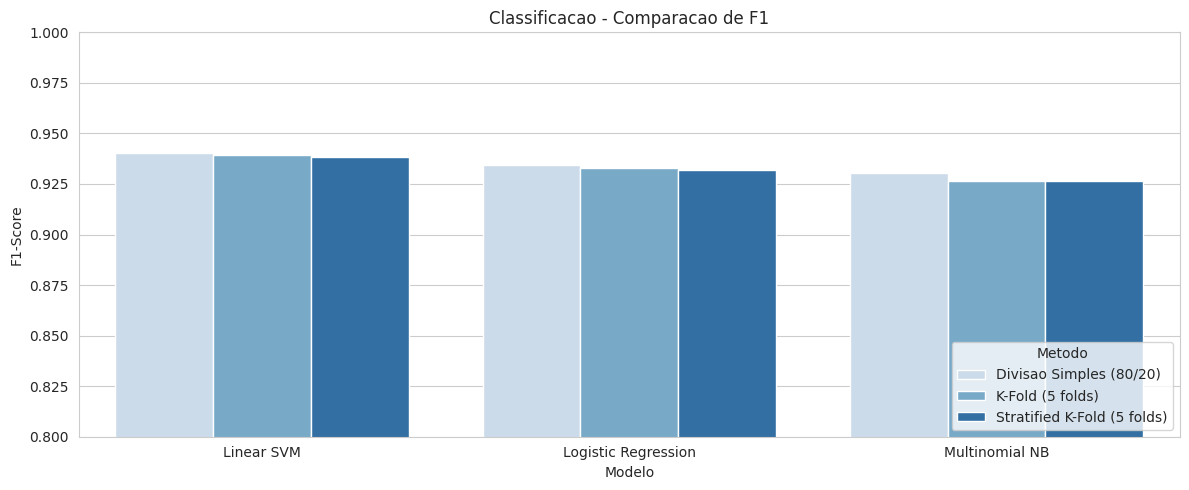

In [21]:
# Grafico comparativo da classificacao (F1 por modelo e metodo)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=resultado_classificacao,
    x='Modelo',
    y='F1',
    hue='Metodo',
    palette='Blues'
)
plt.title('Classificacao - Comparacao de F1')
plt.ylabel('F1-Score')
plt.xlabel('Modelo')
plt.ylim(0.80, 1.00)
plt.legend(title='Metodo', loc='lower right')
plt.tight_layout()
plt.show()


In [22]:
# Identificar a melhor configuracao de classificacao
best_cls = resultado_classificacao.loc[resultado_classificacao['F1'].idxmax()]

print('Melhor configuracao de classificacao:')
print(f"Modelo: {best_cls['Modelo']}")
print(f"Metodo: {best_cls['Metodo']}")
print(f"F1: {best_cls['F1']:.4f}")
print(f"Precisao: {best_cls['Precisao']:.4f} | Recall: {best_cls['Recall']:.4f} | Acuracia: {best_cls['Acuracia']:.4f}")


Melhor configuracao de classificacao:
Modelo: Linear SVM
Metodo: Divisao Simples (80/20)
F1: 0.9403
Precisao: 0.9523 | Recall: 0.9286 | Acuracia: 0.9403


### Interpretacao da Etapa 1 (Classificacao)

- O melhor modelo eh aquele com maior **F1**, pois essa metrica equilibra precisao e recall.
- **Precisao** eh mais importante quando falso positivo tem custo alto.
- **Recall** eh mais importante quando falso negativo tem custo alto.
- **Acuracia** mostra acerto geral, mas sozinha pode esconder falhas em dados desbalanceados.


## 4) Etapa 2 - Regressao


In [23]:
# Confirmar que as separacoes do Topico 1 existem antes da regressao
required_vars_reg = [
    'idx_train_simple',
    'idx_test_simple',
    'kfold_splits',
    'stratified_kfold_reg_splits'
]
missing_reg = [v for v in required_vars_reg if v not in globals()]
if missing_reg:
    raise RuntimeError(f'Execute o Topico 1 primeiro. Faltando: {missing_reg}')

print('Separacoes da regressao prontas para reuso.')


Separacoes da regressao prontas para reuso.


In [24]:
# Definir modelos de regressao (minimo 3 modelos)
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Linear SVR': LinearSVR(max_iter=15000, random_state=42, dual='auto')
}

print('Modelos de regressao:')
for name in reg_models:
    print('-', name)


Modelos de regressao:
- Linear Regression
- Ridge
- Linear SVR


In [25]:
# Funcao para montar pipeline de regressao
# Comentario: a mesma ideia de TF-IDF por fold evita vazamento.
def make_reg_pipeline(model):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            strip_accents='unicode',
            ngram_range=(1, 2),
            min_df=2
        )),
        ('model', model)
    ])


In [26]:
# Funcao para avaliar regressao em uma lista de splits
def evaluate_regression_with_splits(model_dict, splits, method_name):
    rows = []

    for model_name, model in model_dict.items():
        fold_scores = []

        for train_idx, test_idx in splits:
            X_train = X_text.iloc[train_idx]
            X_test = X_text.iloc[test_idx]
            y_train = y_reg.iloc[train_idx]
            y_test = y_reg.iloc[test_idx]

            pipe = make_reg_pipeline(model)
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            fold_scores.append(r2_score(y_test, y_pred))

        rows.append({
            'Metodo': method_name,
            'Modelo': model_name,
            'R2': float(np.mean(fold_scores))
        })

    return pd.DataFrame(rows)


In [27]:
# Avaliar regressao com Divisao Simples (reuso do Topico 1)
res_reg_simple = evaluate_regression_with_splits(
    reg_models,
    [(idx_train_simple, idx_test_simple)],
    'Divisao Simples (80/20)'
)
res_reg_simple.round(4)


,Metodo,Modelo,R2
0,Divisao Simples (80/20),Linear Regression,-0.7997
1,Divisao Simples (80/20),Ridge,0.7310
2,Divisao Simples (80/20),Linear SVR,0.7195


In [28]:
# Avaliar regressao com K-Fold (reuso do Topico 1)
res_reg_kfold = evaluate_regression_with_splits(
    reg_models,
    kfold_splits,
    'K-Fold (5 folds)'
)
res_reg_kfold.round(4)


,Metodo,Modelo,R2
0,K-Fold (5 folds),Linear Regression,-0.7050
1,K-Fold (5 folds),Ridge,0.7310
2,K-Fold (5 folds),Linear SVR,0.7211


In [29]:
# Avaliar regressao com Stratified K-Fold (reuso do Topico 1)
res_reg_strat = evaluate_regression_with_splits(
    reg_models,
    stratified_kfold_reg_splits,
    'Stratified K-Fold (5 folds)'
)
res_reg_strat.round(4)


,Metodo,Modelo,R2
0,Stratified K-Fold (5 folds),Linear Regression,-0.2176
1,Stratified K-Fold (5 folds),Ridge,0.7325
2,Stratified K-Fold (5 folds),Linear SVR,0.7232


In [30]:
# Consolidar resultados de regressao
resultado_regressao = pd.concat(
    [res_reg_simple, res_reg_kfold, res_reg_strat],
    ignore_index=True
)
resultado_regressao = resultado_regressao.sort_values(
    ['Metodo', 'R2'],
    ascending=[True, False]
).reset_index(drop=True)

resultado_regressao_round = resultado_regressao.copy()
resultado_regressao_round['R2'] = resultado_regressao_round['R2'].round(4)

print('Tabela final - Regressao')
print(resultado_regressao_round.to_string(index=False))


Tabela final - Regressao
                     Metodo            Modelo      R2
    Divisao Simples (80/20)             Ridge  0.7310
    Divisao Simples (80/20)        Linear SVR  0.7195
    Divisao Simples (80/20) Linear Regression -0.7997
           K-Fold (5 folds)             Ridge  0.7310
           K-Fold (5 folds)        Linear SVR  0.7211
           K-Fold (5 folds) Linear Regression -0.7050
Stratified K-Fold (5 folds)             Ridge  0.7325
Stratified K-Fold (5 folds)        Linear SVR  0.7232
Stratified K-Fold (5 folds) Linear Regression -0.2176


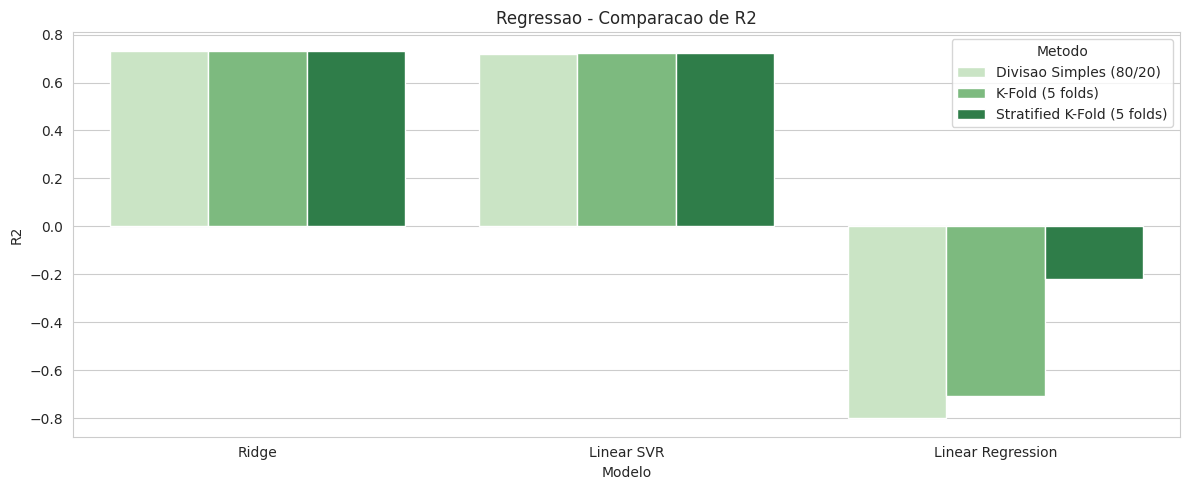

In [31]:
# Grafico comparativo da regressao (R2 por modelo e metodo)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=resultado_regressao,
    x='Modelo',
    y='R2',
    hue='Metodo',
    palette='Greens'
)
plt.title('Regressao - Comparacao de R2')
plt.ylabel('R2')
plt.xlabel('Modelo')
plt.legend(title='Metodo', loc='upper right')
plt.tight_layout()
plt.show()


In [32]:
# Identificar melhor configuracao de regressao
best_reg = resultado_regressao.loc[resultado_regressao['R2'].idxmax()]

print('Melhor configuracao de regressao:')
print(f"Modelo: {best_reg['Modelo']}")
print(f"Metodo: {best_reg['Metodo']}")
print(f"R2: {best_reg['R2']:.4f}")


Melhor configuracao de regressao:
Modelo: Ridge
Metodo: Stratified K-Fold (5 folds)
R2: 0.7325


### Interpretacao da Etapa 2 (Regressao)

- **R2** mede quanta variacao da nota eh explicada pelo modelo.
- Quanto mais perto de **1**, melhor.
- Se **R2 < 0**, o modelo esta pior do que uma previsao simples pela media.


## 5) Conclusao final do projeto

- O projeto foi executado conforme o enunciado: 3 modelos por etapa e 3 metodos de separacao.
- As separacoes criadas no Topico 1 foram reutilizadas nos blocos seguintes.
- A avaliacao foi feita com as metricas exigidas:
  - Classificacao: Acuracia, Precisao, Recall e F1.
  - Regressao: R2.
- Tabelas e graficos foram incluidos para comparacao e interpretacao dos resultados.
